# EDA de la semana 4 · variables, texto, etiqueta y eventos del Anexo 02

**Curso:** MIA-14 Trabajo de Investigación II · **Autor:** Carlos Pérez Pérez

Este cuaderno muestra las tablas y las figuras de la última corrida de `python src/eda.py`. No lee datos de MIMIC-IV: toma los
resultados agregados que el script deja en `reportes/eda_resumen.json`, `reportes/eda_eventos_231.csv` y `reportes/figuras/`.
La lectura de cada resultado está en la sección del EDA del `README.md`.

In [1]:
import json
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

pd.set_option("display.max_rows", 60, "display.max_colwidth", 90, "display.width", 200)
REP = Path("../reportes")
R = json.loads((REP / "eda_resumen.json").read_text(encoding="utf-8"))
V, E, T, P, N = R["variables"], R["eventos"], R["texto"], R["prevalencia_real"], R["ruido_etiqueta"]
fig = lambda nombre: display(Image(filename=str(REP / "figuras" / nombre)))
print("corrida:", R["fecha"], "· epicrisis:", R["entrada"]["notas"], "· pacientes:", R["entrada"]["pacientes"], "· semilla:", R["semilla"])
print(R["alcance"])

corrida: 2026-10-10T19:06:25 · epicrisis: 70000 · pacientes: 48669 · semilla: 42
las cifras describen el corpus completo (train y test); el vocabulario y el modelo de contexto se ajustan solo con train


## Flujo del análisis

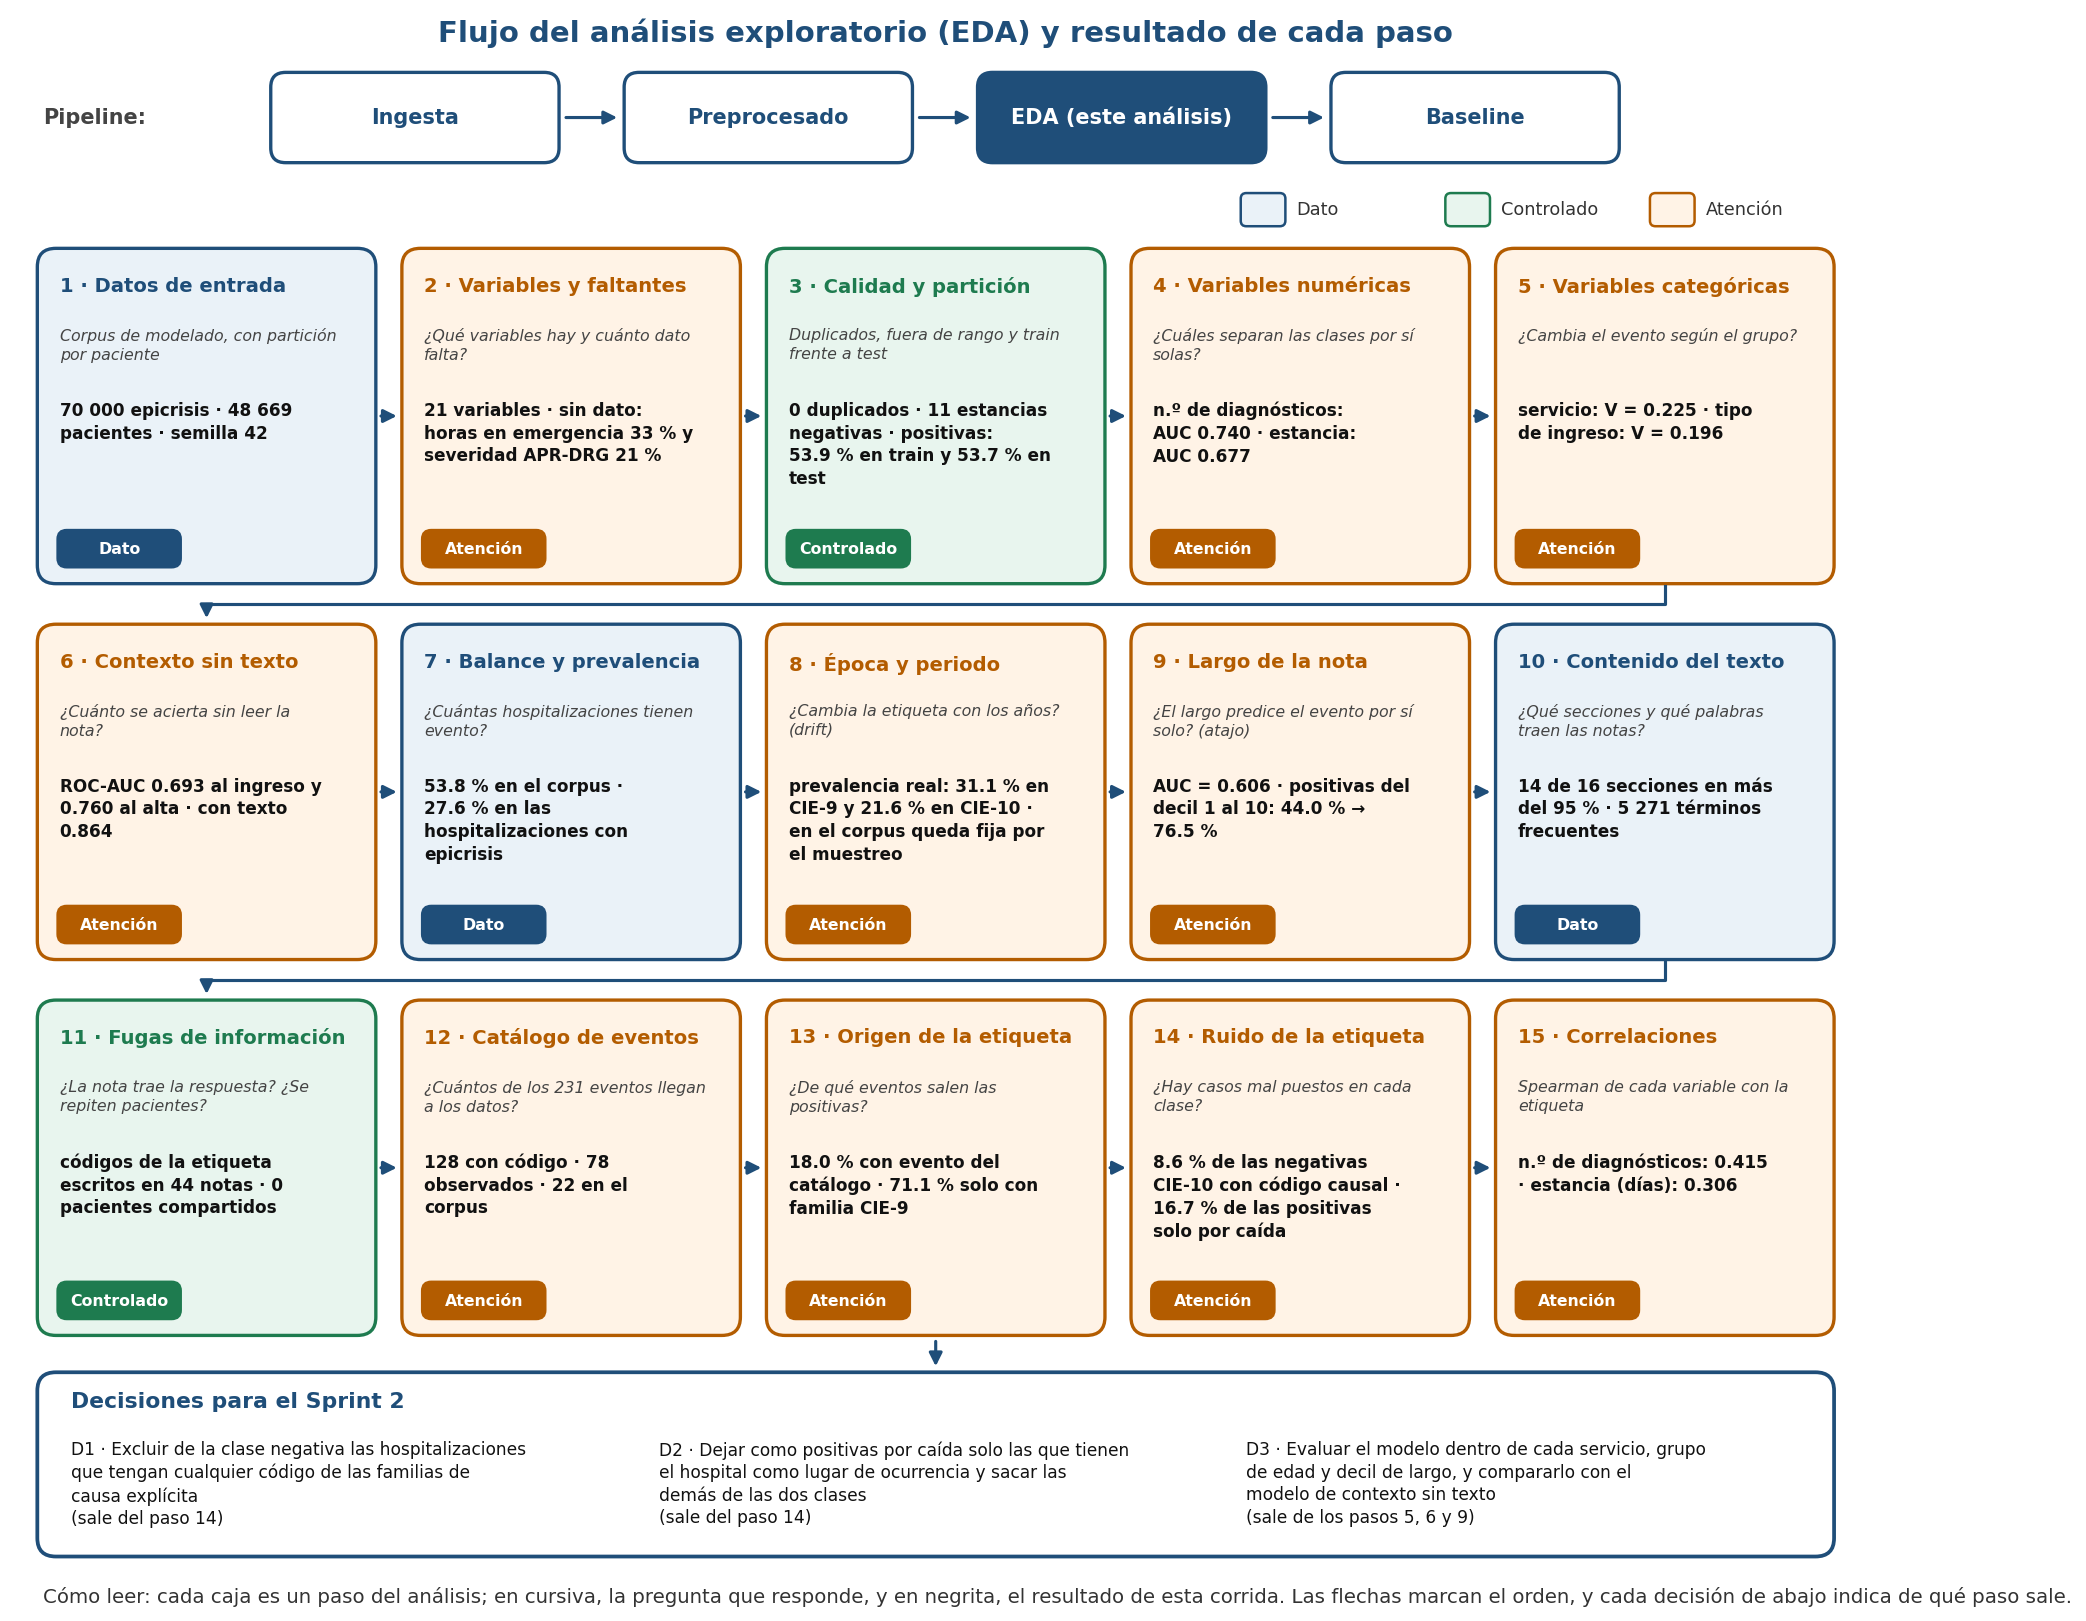

In [2]:
fig("fig_eda_flujo.png")

## 1 · Los datos: calidad, balance y partición

In [3]:
print("duplicados:", R["calidad"]["duplicados"], "· nulos en las columnas del corpus:", R["calidad"]["nulos"]["columnas_sin_labels"])
print("atípicos por largo:", R["calidad"]["outliers_largo"]["n"], "· estancias negativas:", V["fuera_de_rango"]["estancia_negativa"])
display(pd.DataFrame(R["descriptivas"]).T[["mean", "50%", "std", "min", "max"]].rename(columns={"mean": "media", "50%": "mediana", "std": "desv"}))
display(pd.DataFrame({k: R["balance"][k] for k in ("train", "test", "All")}).T)
display(pd.DataFrame(V["particion"]).T.round(2))

duplicados: {'note_id': 0, 'hadm_id': 0, 'texto_identico': 0} · nulos en las columnas del corpus: 0
atípicos por largo: 1933 · estancias negativas: 11


,media,mediana,desv,min,max
largo_caracteres,10684.00,9932.0,4642.76,353.0,58156.0
palabras,1621.89,1515.0,694.56,44.0,9026.0
notas_por_paciente,1.44,1.0,1.12,1.0,27.0
naturalezas_por_positiva,1.06,1.0,0.26,1.0,5.0


,negativa,positiva,total,pct_positivas
train,25780.0,30135.0,55915.0,53.894304
test,6528.0,7557.0,14085.0,53.652822
All,32308.0,37692.0,70000.0,53.845714


,n,pct_positivas,mediana_edad,mediana_estancia_dias,mediana_largo,pct_hombres,pct_uci,pct_cie10,pct_cie10_positivas,pct_cie10_negativas,auc_epoca_sola
train,55915.0,53.89,64.0,3.88,9915.0,49.31,21.68,28.65,28.46,28.86,0.50
test,14085.0,53.65,63.0,3.88,10001.0,50.04,21.35,30.03,30.78,29.17,0.51


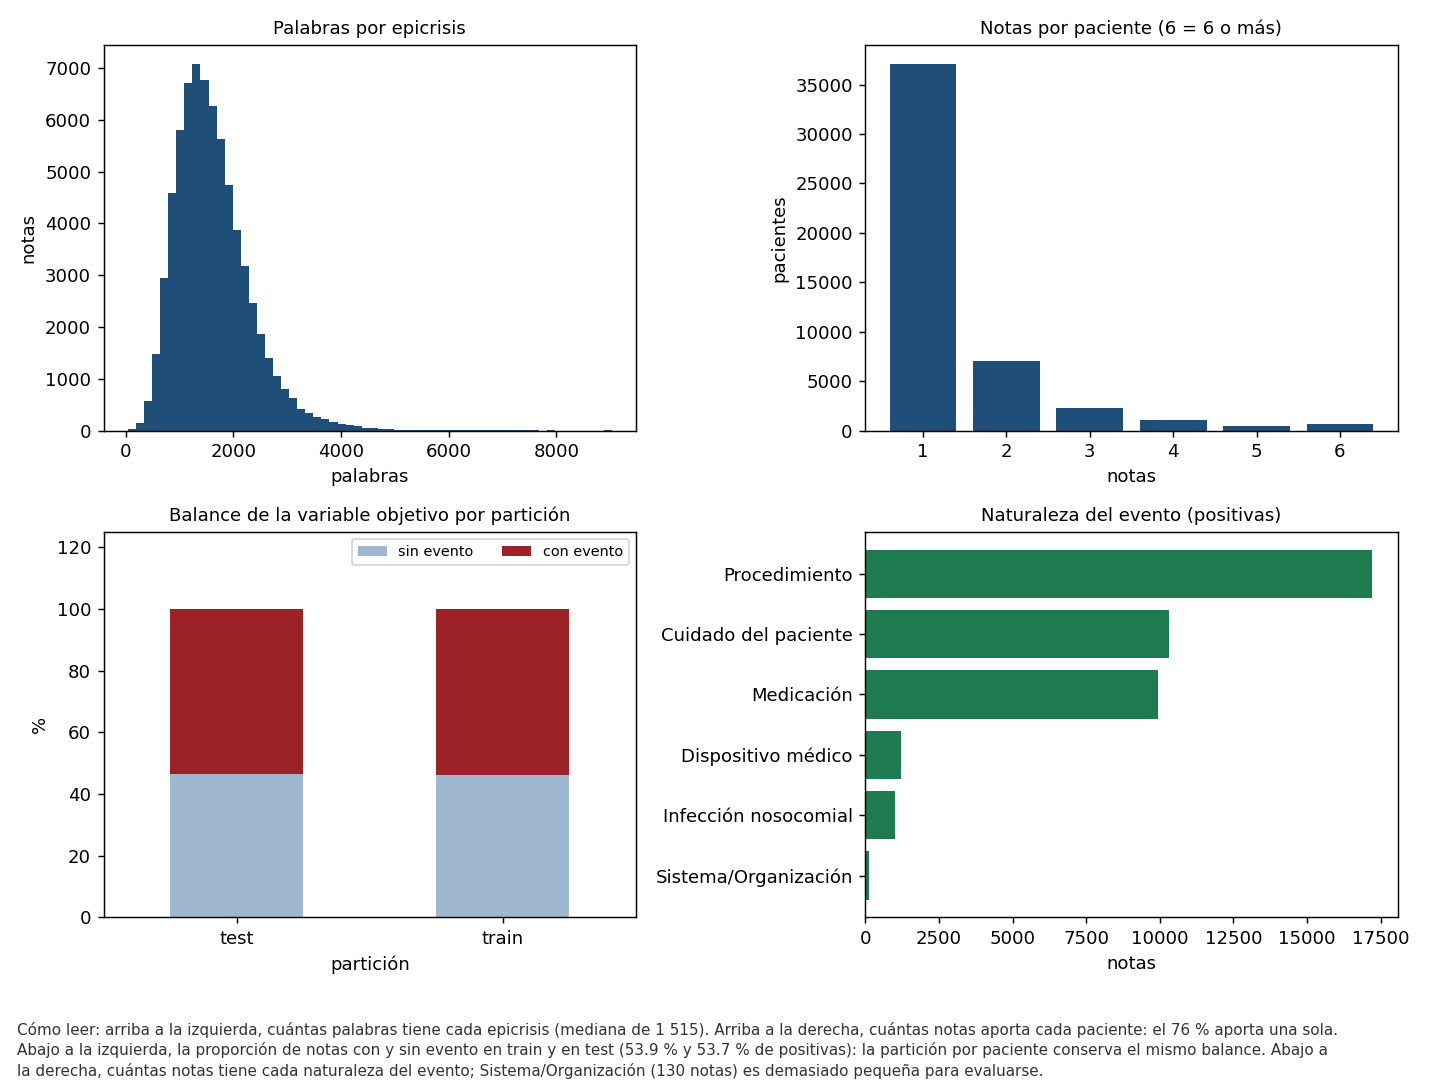

In [4]:
fig("fig_eda_distribuciones.png")

## 2 · Las variables de cada hospitalización
### Diccionario y datos faltantes

In [5]:
dic = pd.DataFrame(V["diccionario"])
display(dic[["etiqueta", "tipo", "fuente", "momento", "uso", "pct_faltantes", "pct_positivas_si_falta", "pct_positivas_si_no_falta"]].round(2))
display(pd.DataFrame(V["faltantes_por_tipo_ingreso"]).round(1))

,etiqueta,tipo,fuente,momento,uso,pct_faltantes,pct_positivas_si_falta,pct_positivas_si_no_falta
0,Edad al ingreso (años),numérica,"patients, admissions",ingreso,descripción y sesgo,0.00,NaN,NaN
1,Sexo,categórica,patients,ingreso,descripción y sesgo,0.00,NaN,NaN
2,Raza o etnia (agrupada),categórica,admissions,ingreso,descripción y sesgo,3.74,58.53,53.66
3,Tipo de seguro,categórica,admissions,ingreso,descripción y sesgo,1.07,40.27,53.99
4,Idioma inglés,binaria,admissions,ingreso,descripción y sesgo,0.23,60.87,53.83
5,Estado civil,categórica,admissions,ingreso,descripción,2.33,60.77,53.68
6,Tipo de ingreso,categórica,admissions,ingreso,control,0.00,NaN,NaN
7,Servicio al ingreso,categórica,services,ingreso,control y evaluación por subgrupo,0.00,NaN,NaN
8,Horas en emergencia,numérica,admissions,ingreso,control,33.20,55.32,53.11
9,Periodo de atención (año aproximado),categórica,"patients, admissions",ingreso,drift temporal,0.00,NaN,NaN


,horas_emergencia,drg_severidad,destino_alta
EW EMER.,4.2,6.1,0.2
OBSERVATION ADMIT,15.4,4.8,0.0
URGENT,72.4,7.1,0.1
SURGICAL SAME DAY ADMISSION,99.9,25.1,0.2
EU OBSERVATION,1.0,97.7,97.2
DIRECT EMER.,92.7,17.0,0.2
ELECTIVE,99.4,35.4,0.2
DIRECT OBSERVATION,77.0,97.2,96.8
AMBULATORY OBSERVATION,98.5,99.1,99.4


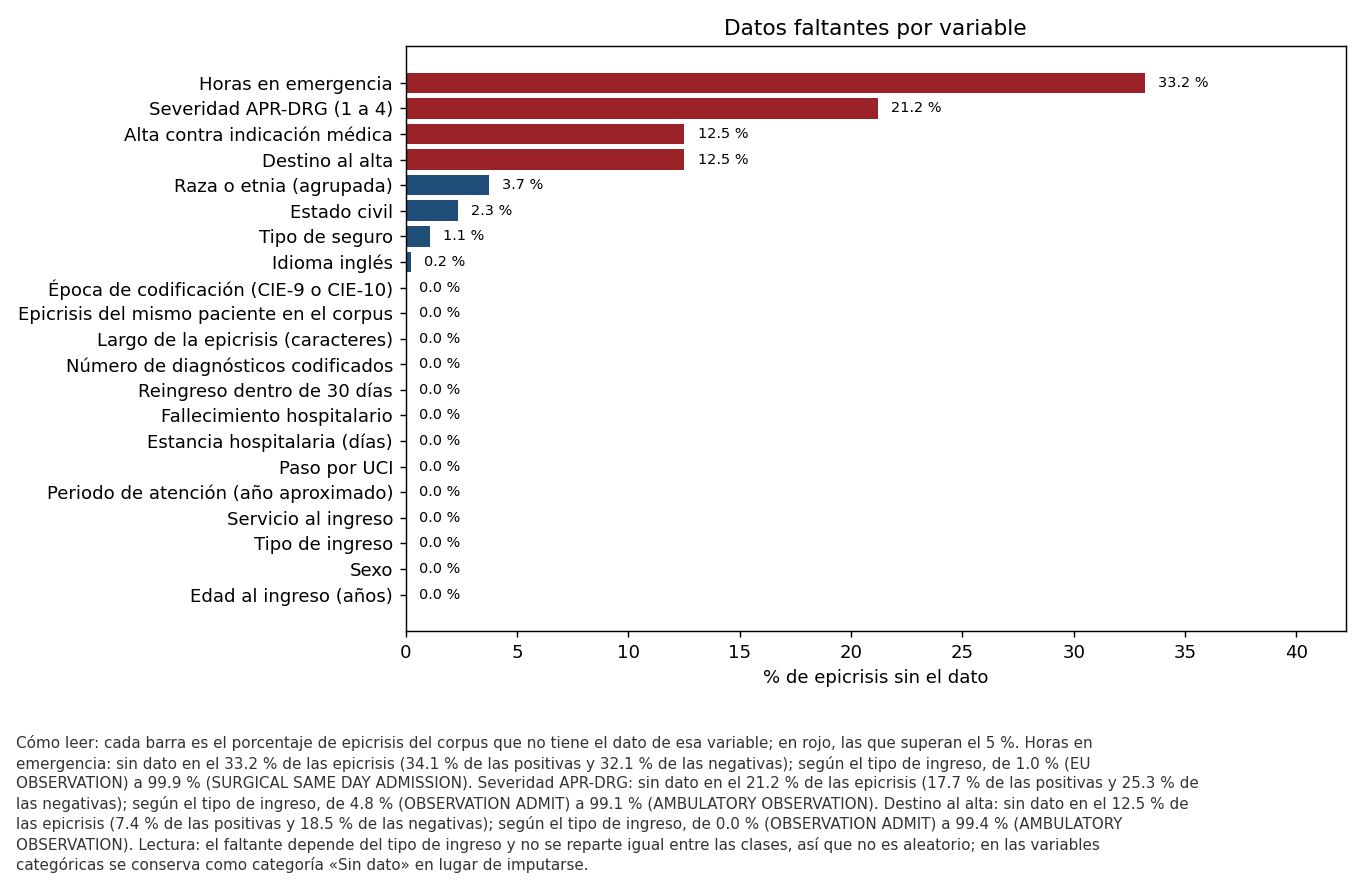

In [6]:
fig("fig_eda_faltantes.png")

### Variables numéricas

In [7]:
num = pd.DataFrame({k: {"media": v["media"], "desv": v["desv"], "mín": v["min"], "q1": v["q1"], "mediana": v["mediana"], "q3": v["q3"],
                        "máx": v["max"], "% atípicos": v["atipicos_iqr"]["pct"], "mediana sin evento": v["negativa"]["mediana"],
                        "mediana con evento": v["positiva"]["mediana"], "AUC sola": v["auc_sola"], "Spearman con y": v["spearman_con_y"]}
                    for k, v in V["numericas"].items()}).T
display(num.round(3))

,media,desv,mín,q1,mediana,q3,máx,% atípicos,mediana sin evento,mediana con evento,AUC sola,Spearman con y
edad,62.358,17.794,18.000,51.000,64.000,76.000,103.000,0.000,61.000,66.000,0.583,0.144
estancia_dias,6.140,8.121,-0.945,1.992,3.882,6.979,230.689,8.107,2.882,4.995,0.677,0.306
horas_emergencia,7.671,5.575,0.000,4.583,6.333,8.850,139.333,7.154,6.433,6.250,0.486,-0.025
n_diagnosticos,13.587,7.634,1.000,8.000,12.000,18.000,57.000,2.106,9.000,15.000,0.740,0.415
drg_severidad,2.522,0.916,1.000,2.000,3.000,3.000,4.000,0.000,2.000,3.000,0.662,0.293
largo,10683.995,4642.764,353.000,7453.000,9932.000,13024.250,58156.000,2.761,9185.000,10717.000,0.606,0.182
notas_paciente,2.317,2.401,1.000,1.000,1.000,3.000,27.000,5.549,1.000,2.000,0.566,0.125


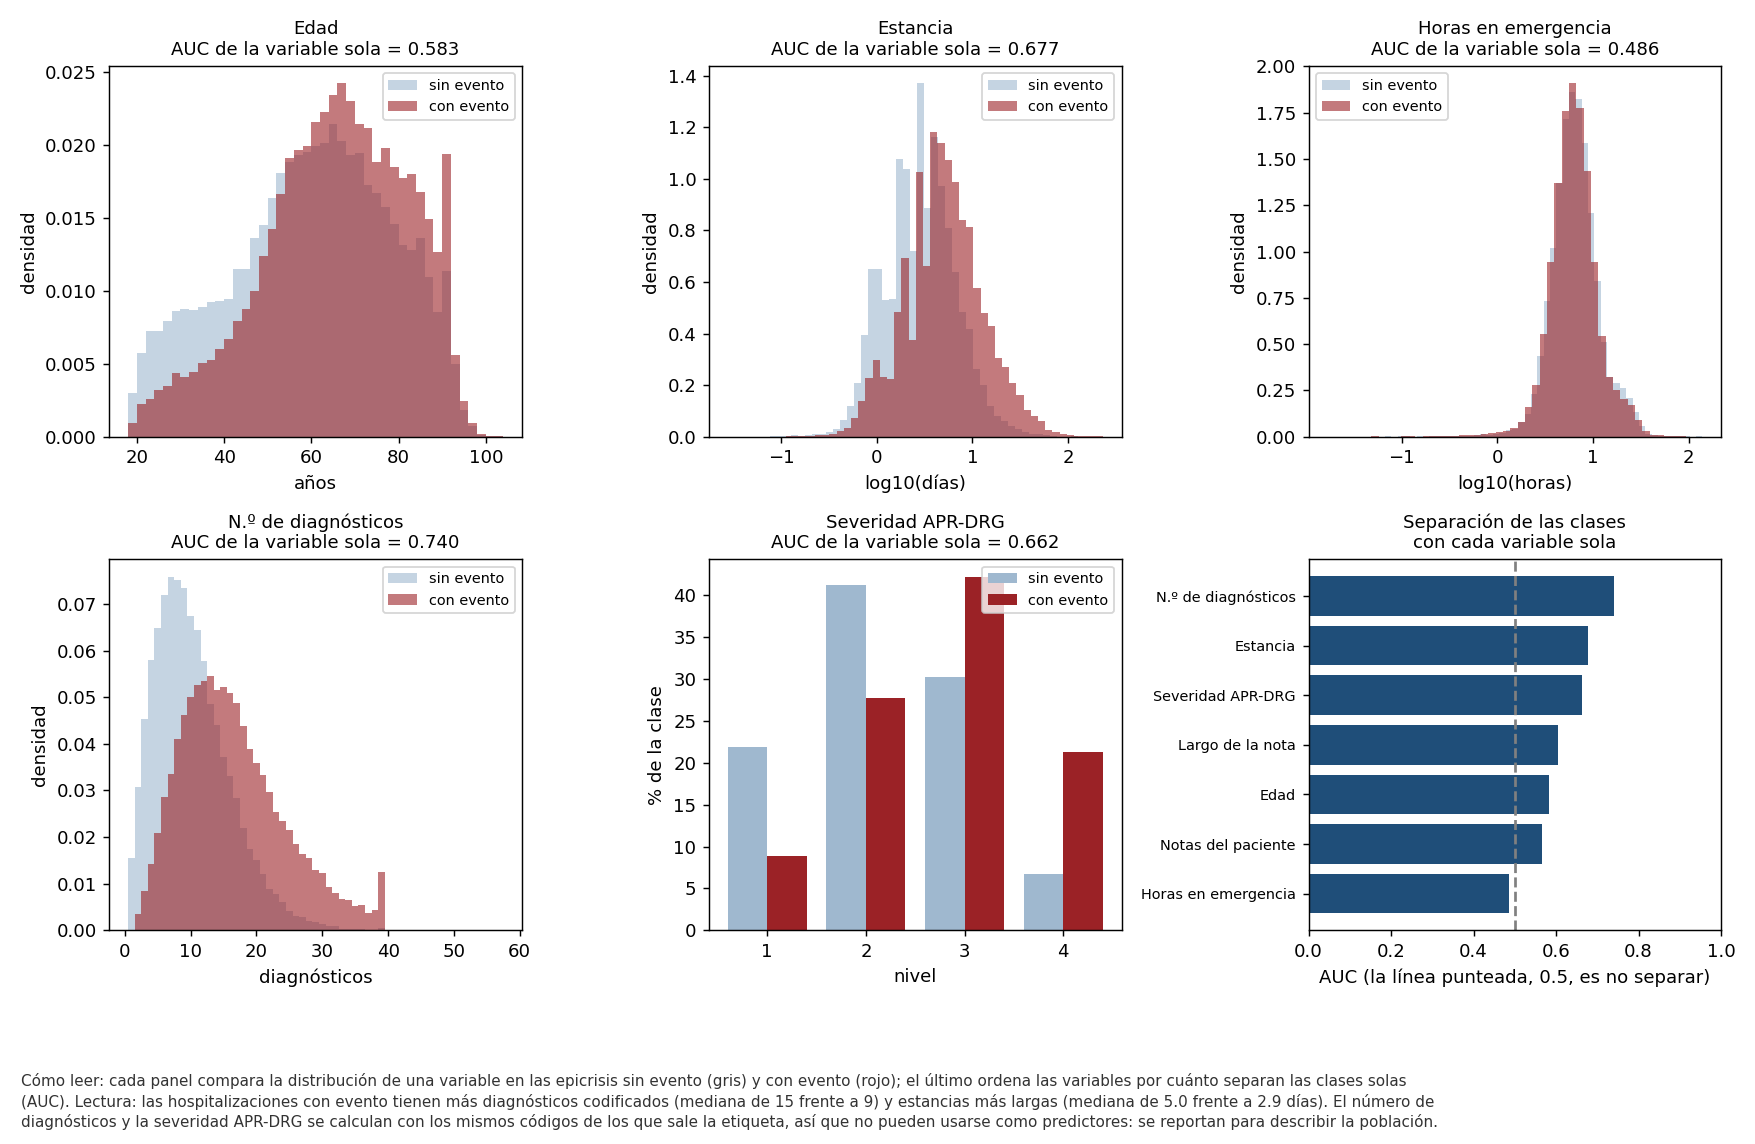

In [8]:
fig("fig_eda_numericas.png")

### Variables categóricas

In [9]:
display(pd.Series({k: v["cramers_v"] for k, v in V["categoricas"].items()}, name="V de Cramér con la etiqueta").sort_values(ascending=False).round(3).to_frame())
for v in ("servicio", "tipo_ingreso", "destino_alta", "grupo_edad", "sexo", "raza", "seguro"):
    display(pd.DataFrame(V["categoricas"][v]["categorias"]).T[["n", "pct_positivas"]].sort_values("pct_positivas", ascending=False).round(1).rename_axis(v))

,V de Cramér con la etiqueta
destino_alta,0.317
servicio,0.225
tipo_ingreso,0.196
alta_voluntaria,0.169
grupo_edad,0.148
uci,0.144
seguro,0.123
raza,0.081
estado_civil,0.072
fallecio,0.065


,n,pct_positivas
servicio,,
TRAUM,1472.0,71.7
VSURG,2318.0,71.6
OMED,5421.0,69.5
ORTHO,4620.0,65.7
CSURG,1723.0,61.1
NSURG,2667.0,59.1
PSURG,692.0,55.9
SURG,7482.0,55.2
TSURG,831.0,53.5


,n,pct_positivas
tipo_ingreso,,
DIRECT EMER.,4820.0,67.8
ELECTIVE,2402.0,61.4
OBSERVATION ADMIT,8600.0,59.0
URGENT,6547.0,58.1
EW EMER.,32347.0,56.9
SURGICAL SAME DAY ADMISSION,6378.0,44.9
AMBULATORY OBSERVATION,931.0,39.4
DIRECT OBSERVATION,2094.0,32.0
EU OBSERVATION,5881.0,30.2


,n,pct_positivas
destino_alta,,
CHRONIC/LONG TERM ACUTE CARE,2007.0,81.5
REHAB,2726.0,75.1
SKILLED NURSING FACILITY,10579.0,73.8
DIED,1875.0,73.5
HOSPICE,740.0,68.6
ASSISTED LIVING,101.0,64.4
HOME HEALTH CARE,16368.0,62.4
ACUTE HOSPITAL,345.0,61.2
OTHER FACILITY,283.0,59.7


,n,pct_positivas
grupo_edad,,
80 o más,13241.0,61.9
65 a 79,20588.0,58.0
45 a 64,24420.0,53.1
18 a 44,11751.0,39.0


,n,pct_positivas
sexo,,
Hombre,34618.0,55.3
Mujer,35382.0,52.4


,n,pct_positivas
raza,,
Sin dato,2621.0,58.5
Blanca,49645.0,55.9
Otra,2490.0,51.9
Asiática,2124.0,50.0
Negra,9661.0,46.4
Hispana o latina,3459.0,44.9


,n,pct_positivas
seguro,,
Medicare,36079.0,59.7
Other,1735.0,51.5
Private,20896.0,48.0
Medicaid,10522.0,46.7
Sin dato,750.0,40.3


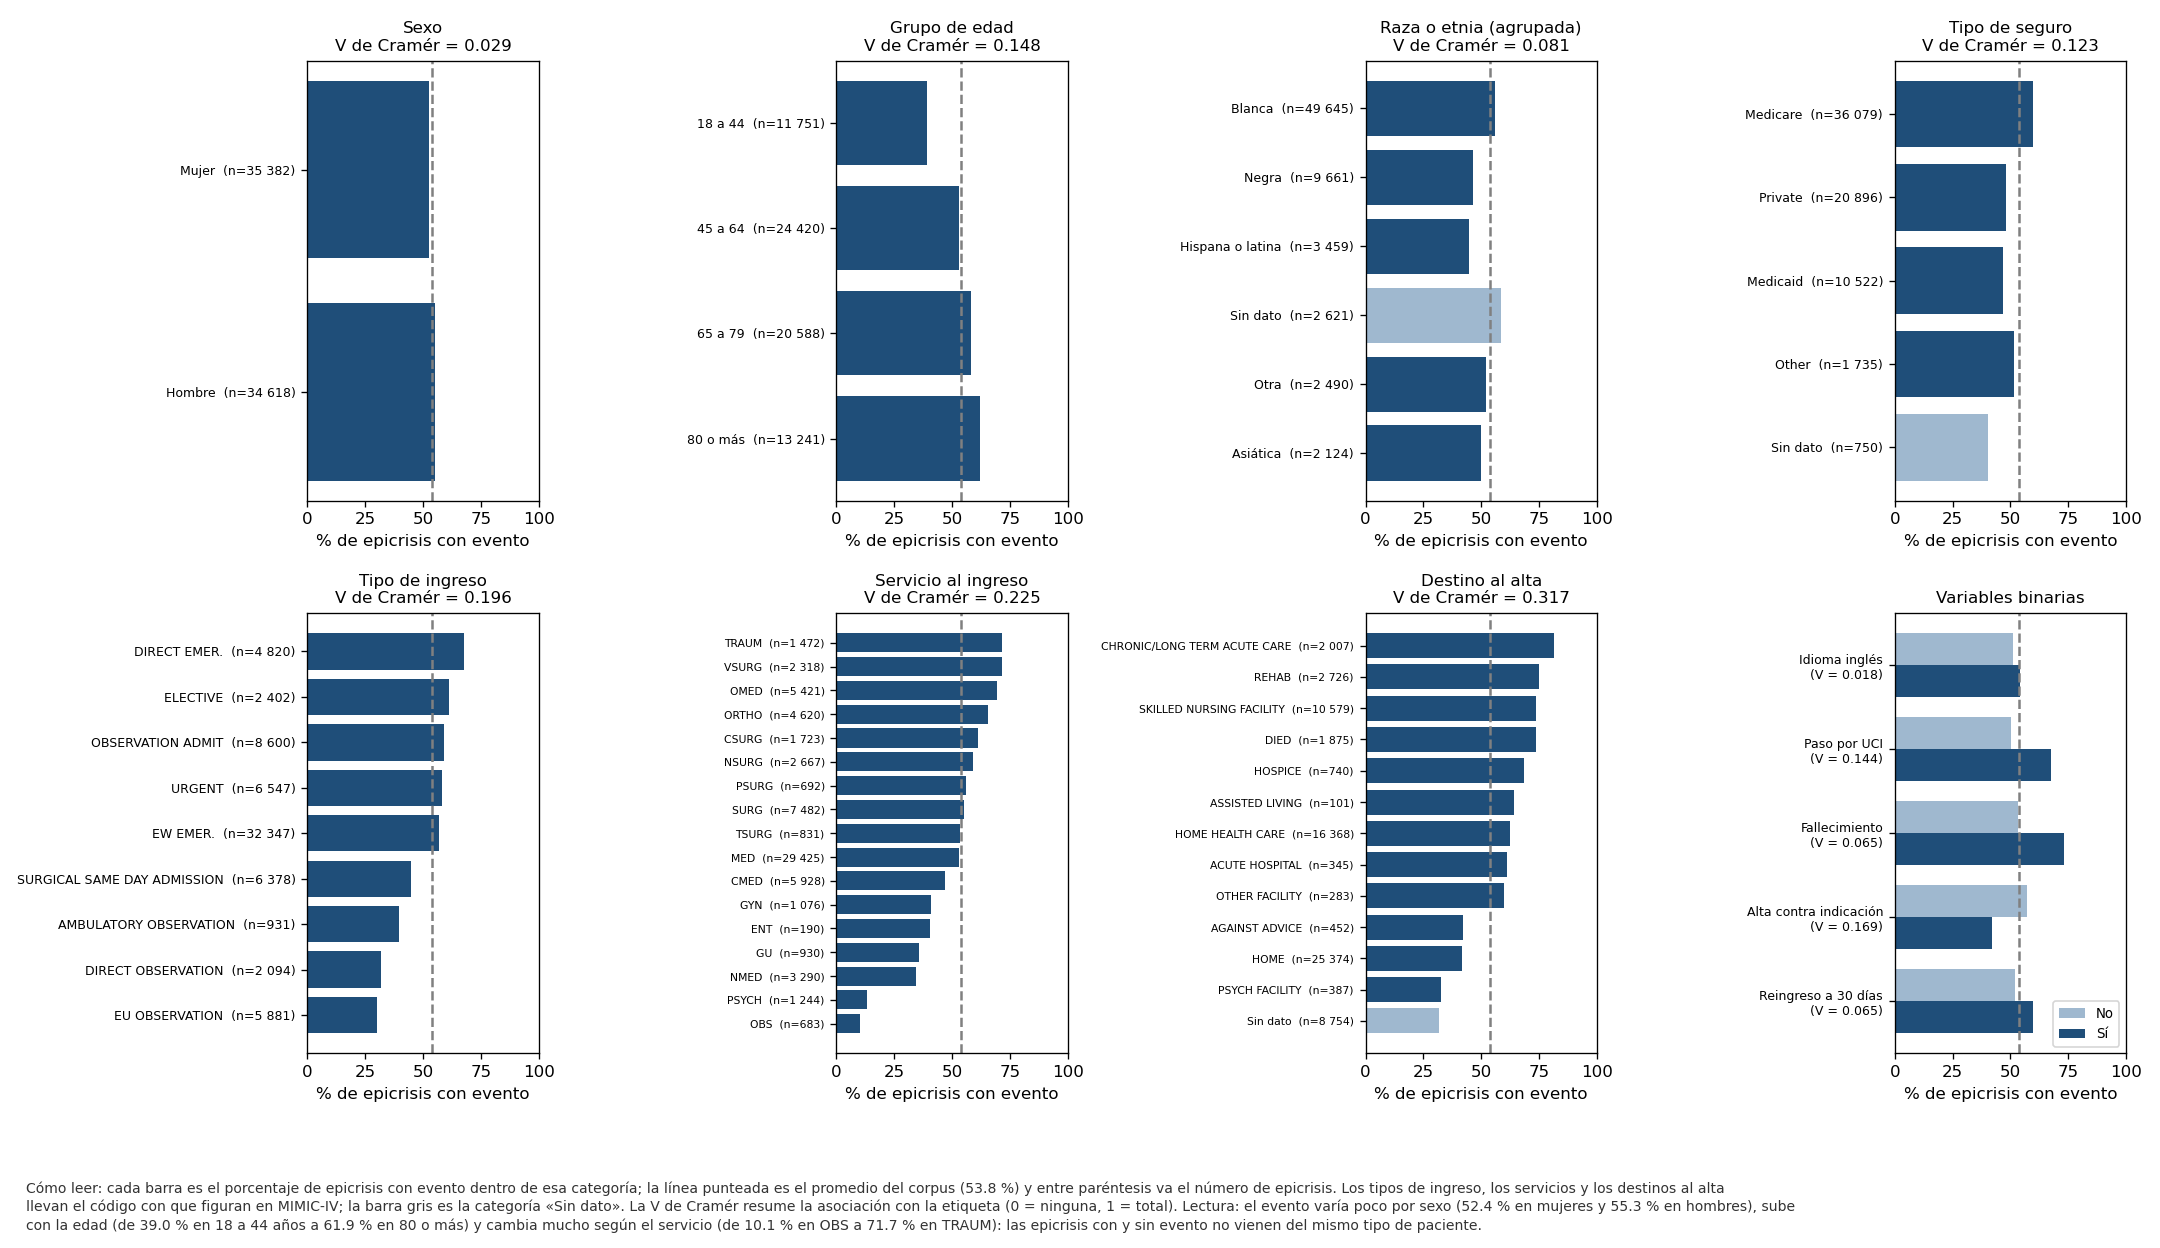

In [10]:
fig("fig_eda_categoricas.png")

,a,b,cramers_v
0,epoca,tipo_ingreso,0.579
1,uci,destino_alta,0.394
2,seguro,grupo_edad,0.380
3,uci,servicio,0.352
4,destino_alta,tipo_ingreso,0.352


,CIE-9,CIE-10
AMBULATORY OBSERVATION,1.7,0.4
DIRECT EMER.,8.1,3.9
DIRECT OBSERVATION,2.1,5.1
ELECTIVE,3.4,3.5
EU OBSERVATION,8.9,7.2
EW EMER.,57.1,19.6
OBSERVATION ADMIT,0.9,40.2
SURGICAL SAME DAY ADMISSION,8.5,10.6
URGENT,9.3,9.5


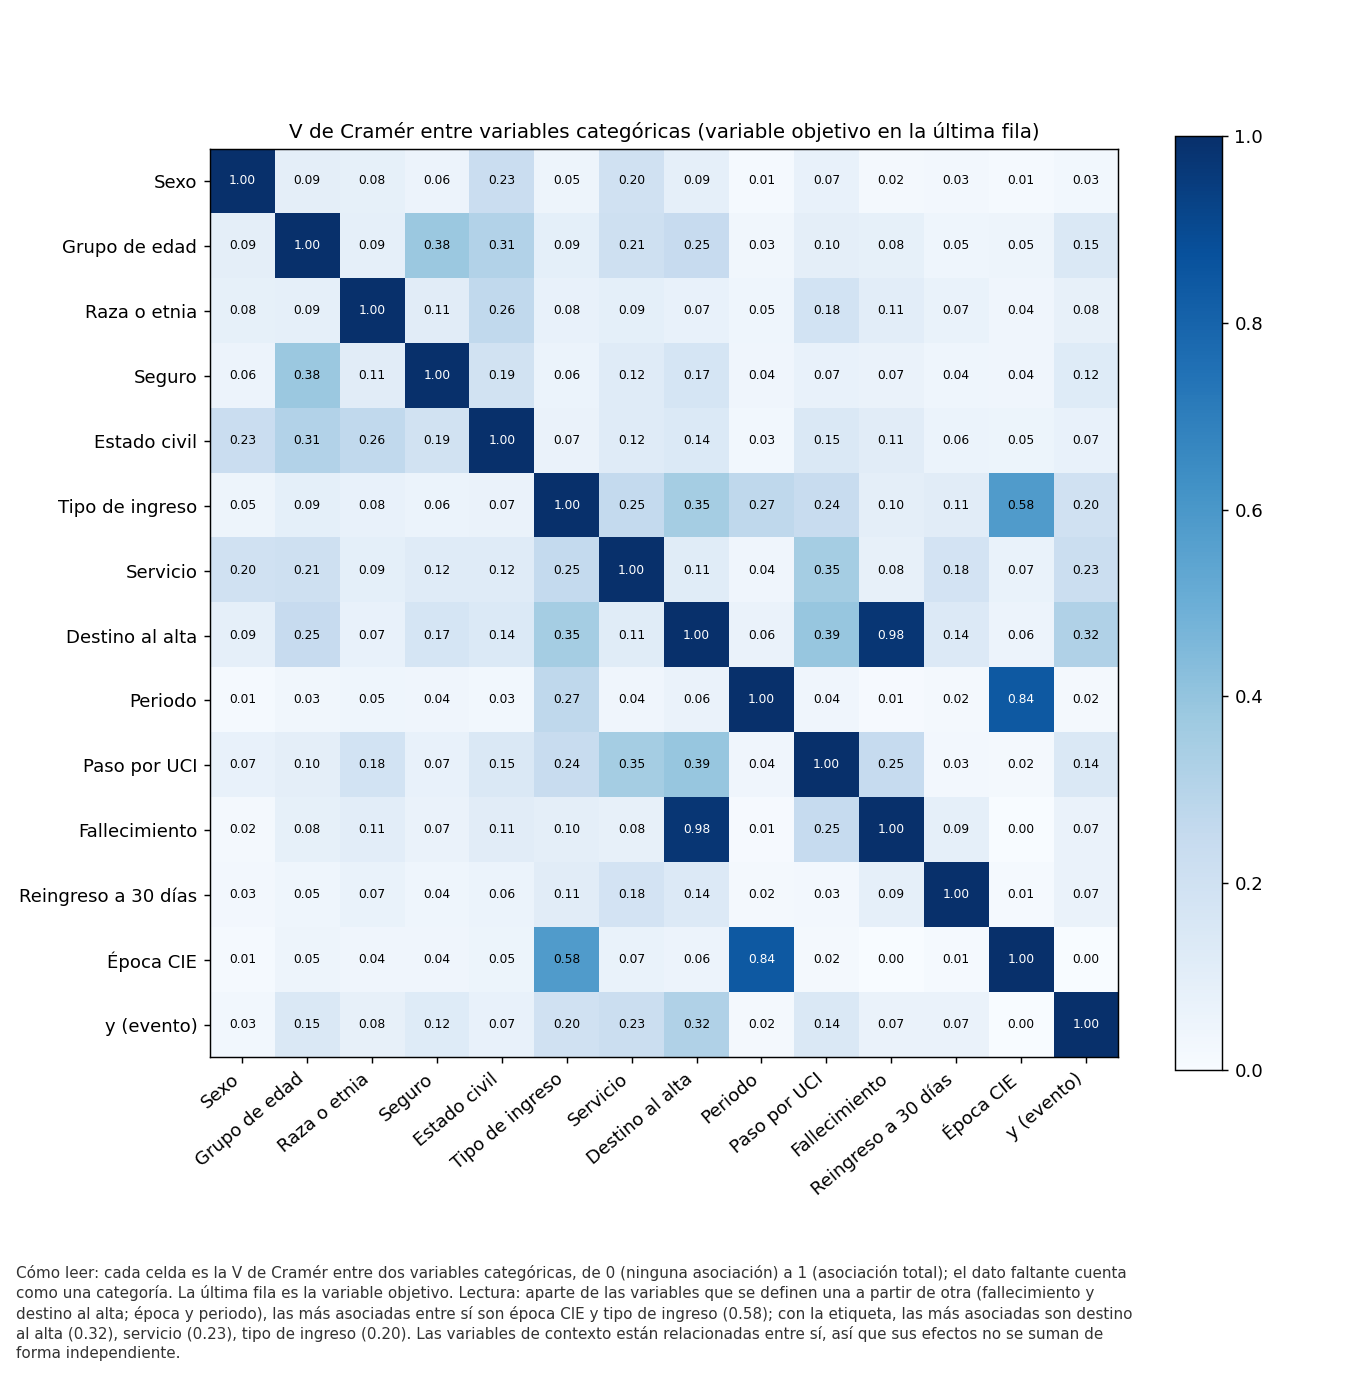

In [11]:
display(pd.DataFrame(V["asociacion_categoricas"]["pares_mas_asociados"]).round(3))
display(pd.DataFrame(V["tipo_ingreso_por_epoca"]).T.round(1))
fig("fig_eda_asociacion.png")

### ¿Cuánto se acierta sin leer la nota?

,ROC-AUC,IC 95 % ROC-AUC,PR-AUC
al_ingreso,0.6926,"[0.683347, 0.700959]",0.7077
al_alta,0.7603,"[0.75233, 0.768714]",0.7818
modelo_de_texto,0.8637,"[0.8581, 0.8691]",0.8787
dummy,0.5,,0.5365


regresión logística sin texto, ajustada en train y medida en test con la partición del pipeline; no incluye el número de diagnósticos ni la severidad APR-DRG; IC 95 % con 500 remuestreos de pacientes


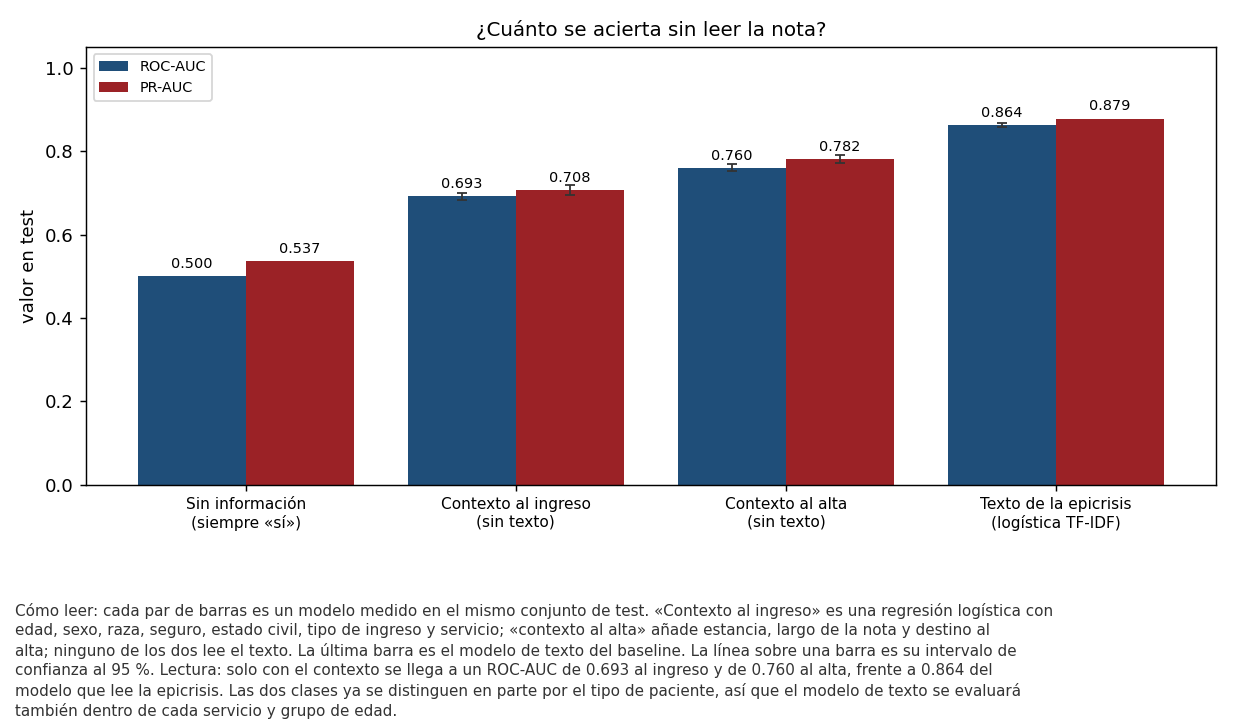

In [12]:
ctx = V["contexto"]
display(pd.DataFrame({k: {"ROC-AUC": v["roc_auc"], "IC 95 % ROC-AUC": v.get("roc_auc_ic95", ""), "PR-AUC": v["pr_auc"]}
                      for k, v in ctx.items() if isinstance(v, dict)}).T)
print(ctx["nota"])
fig("fig_eda_contexto.png")

## 3 · El texto de la epicrisis
### Largo de la nota

mediana por clase: {'negativa': 9185.0, 'positiva': 10717.0} · AUC del largo solo: 0.6056
% de positivas por decil de largo: [44.0, 46.1, 45.5, 46.8, 49.6, 51.3, 55.2, 59.0, 64.5, 76.5]


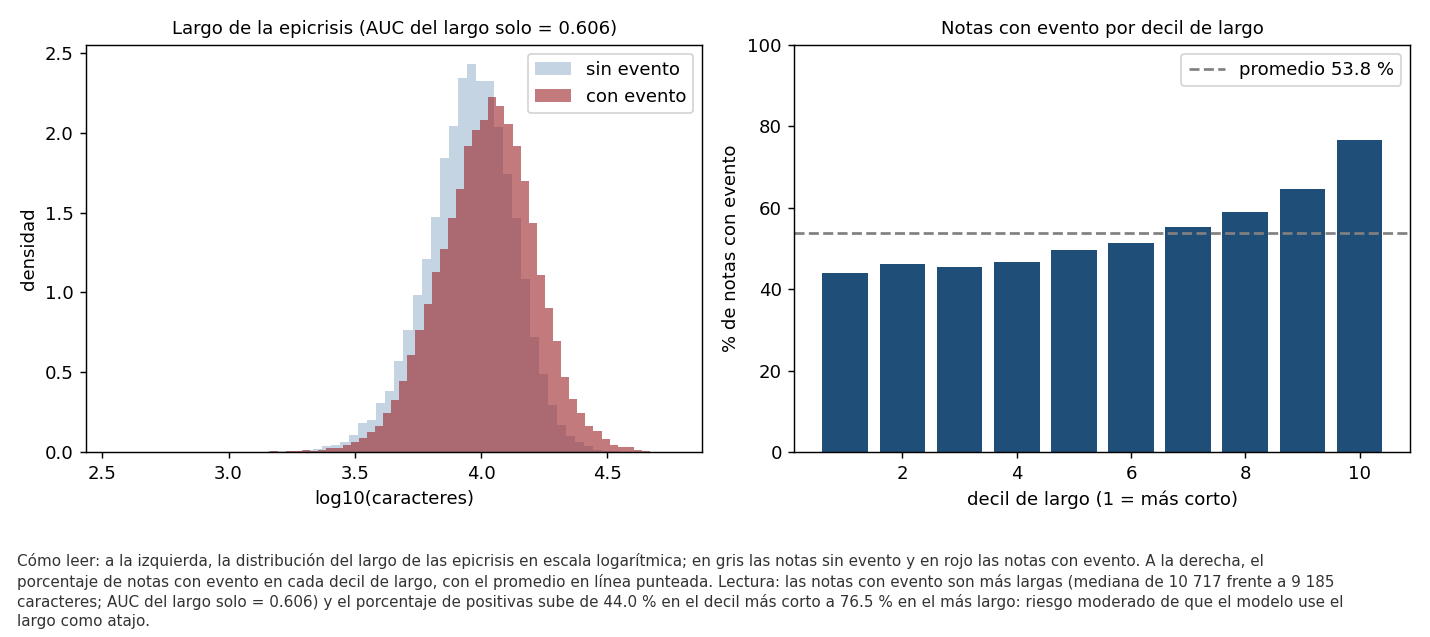

In [13]:
print("mediana por clase:", R["largo"]["mediana_por_clase"], "· AUC del largo solo:", R["largo"]["auc_largo_solo"])
print("% de positivas por decil de largo:", [round(x, 1) for x in R["largo"]["pct_positivas_por_decil"]])
fig("fig_eda_largo.png")

### Secciones y vocabulario

In [14]:
display(pd.DataFrame(T["secciones"]["por_seccion"]).T.round(2))
print({k: v for k, v in T["secciones"].items() if k != "por_seccion"})
display(pd.DataFrame(T["vocabulario"]["mas_asociados_al_evento"]).set_index("termino"))
display(pd.DataFrame(T["vocabulario"]["mas_asociados_a_sin_evento"]).set_index("termino"))

,pct,pct_negativas,pct_positivas
Chief Complaint,96.76,96.97,96.59
Major Surgical or Invasive Procedure,99.49,99.61,99.38
History of Present Illness,98.69,98.59,98.78
Past Medical History,98.80,98.69,98.90
Social History,97.63,97.39,97.84
Family History,97.21,96.96,97.43
Physical Exam,96.50,96.42,96.57
Pertinent Results,96.16,95.82,96.45
Brief Hospital Course,88.15,88.31,88.01
Medications on Admission,94.44,94.72,94.20


{'presentes_en_mas_del_95_pct': 14, 'mediana_por_nota': 16.0, 'pct_notas_con_todas': 67.802857, 'pct_notas_con_menos_de_12': 1.185714, 'auc_numero_de_secciones': 0.4926}


,pct_positivas,pct_negativas,log_odds,z
termino,,,,
facility,63.77,38.24,1.044,59.5
vancomycin,27.41,10.95,1.122,47.2
fracture,28.88,13.58,0.949,42.8
extended,42.62,25.76,0.761,41.4
wound,34.26,18.52,0.830,41.3
line,30.39,15.80,0.844,39.9
cefepime,16.22,5.21,1.258,39.2
placement,34.39,19.57,0.767,38.7
picc,14.29,4.11,1.357,38.3


,pct_positivas,pct_negativas,log_odds,z
termino,,,,
independent,42.27,58.19,-0.642,-37.4
ambulatory,63.11,72.92,-0.454,-24.7
prosody,1.36,4.96,-1.332,-23.2
home,90.35,95.33,-0.780,-22.0
psychiatric,5.59,10.39,-0.671,-20.8
knowledge,1.52,4.57,-1.128,-20.3
psychiatrist,1.87,5.03,-1.022,-20.0
cocaine,3.43,7.23,-0.786,-19.8
behavior,1.80,4.88,-1.029,-19.8


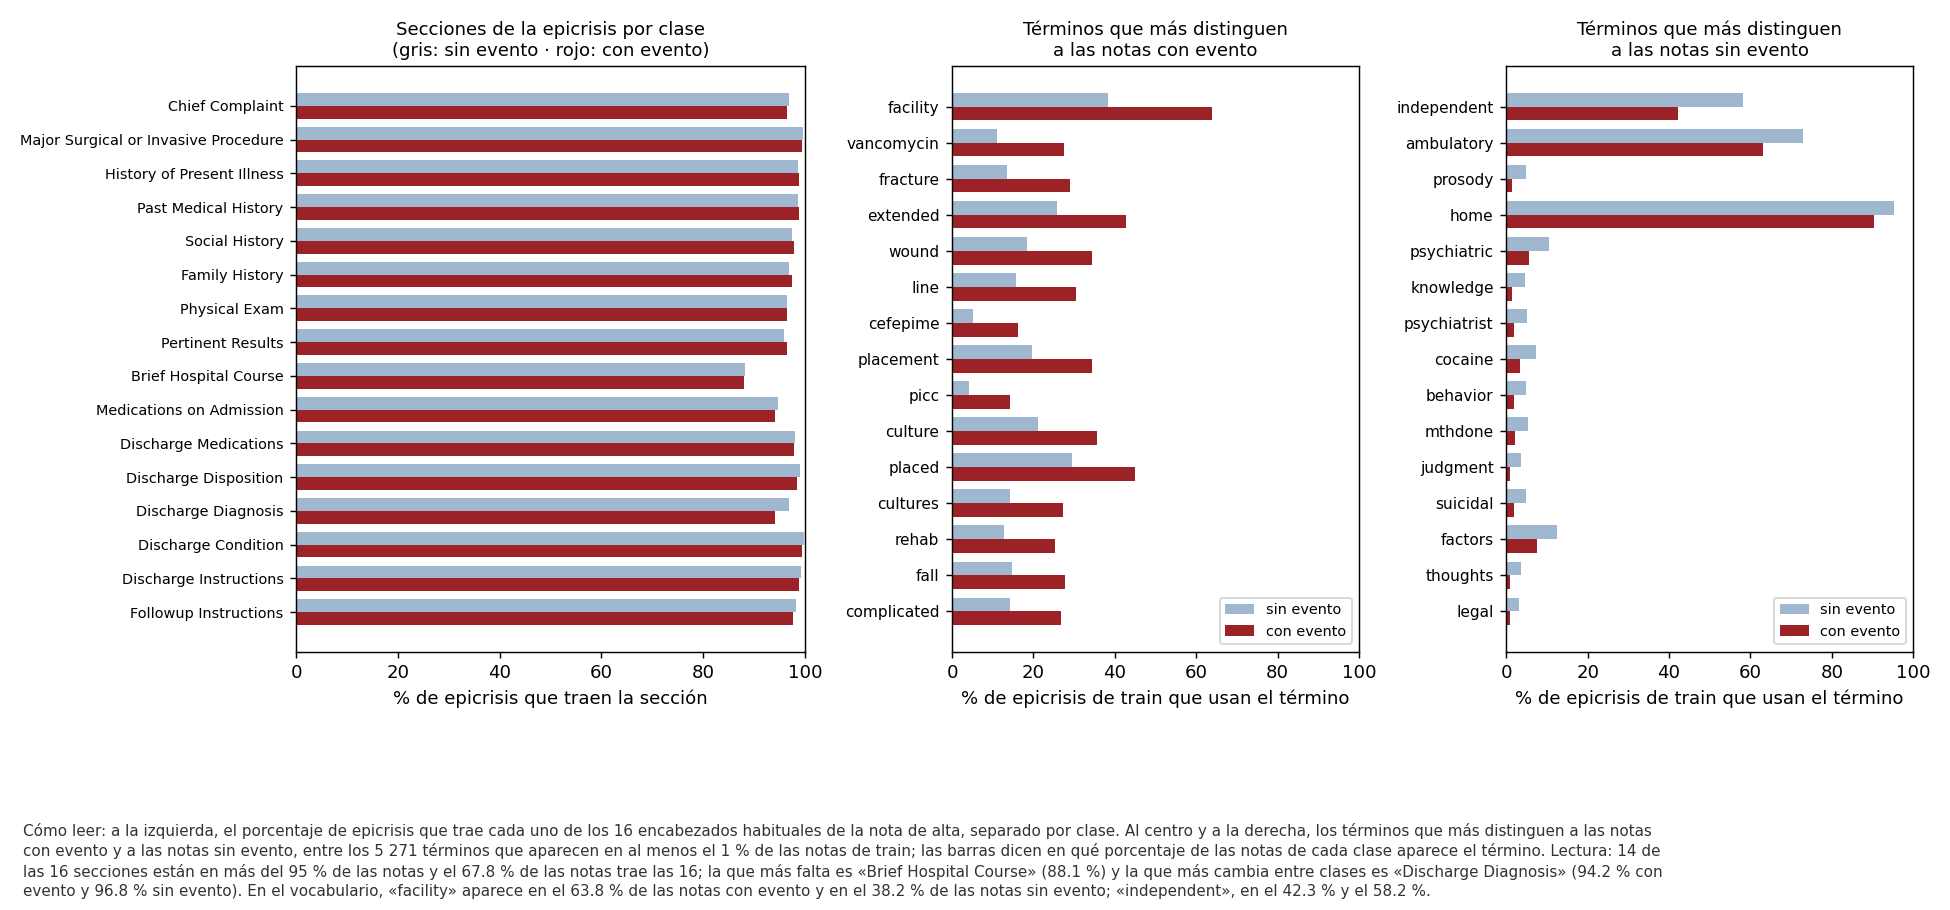

In [15]:
fig("fig_eda_texto.png")

### Fugas de información

In [16]:
print("patrón general (cualquier cadena con forma de código):", R["fuga_codigos"]["patron_general"])
print("familias de la etiqueta:", R["fuga_codigos"]["familias_de_la_etiqueta"])
print("pacientes compartidos entre train y test:", R["pacientes"]["compartidos_train_test"])

patrón general (cualquier cadena con forma de código): {'notas': 3306, 'pct_positivas': 4.953306, 'pct_negativas': 4.454005, 'coincidencias': 4241, 'pct_coincidencias_T95_a_T99': 72.459326, 'pct_notas_con_solo_T95_a_T99': 74.440411, 'cadenas_mas_frecuentes': {'T98.2': 247, 'T98.1': 244, 'T98.3': 202, 'T98.4': 191, 'T97.9': 176, 'T97.8': 176}, 'codigos_T95_a_T99_en_el_diccionario_de_mimic': 0, 'nota': 'letra, dos dígitos, punto y decimales; también captura valores como una temperatura escrita T98.2'}
familias de la etiqueta: {'notas': 44, 'positivas': 37, 'negativas': 7, 'pct_positivas': 0.098164, 'pct_negativas': 0.021666, 'codigos_cie10': {'notas': 20, 'positivas': 20, 'negativas': 0, 'pct_positivas': 0.053062, 'pct_negativas': 0.0}, 'codigos_cie9': {'notas': 24, 'positivas': 17, 'negativas': 7, 'pct_positivas': 0.045102, 'pct_negativas': 0.021666}, 'nota': 'búsqueda por patrón de los códigos escritos con punto; un número con la misma forma (996.5) también cuenta, así que es una cota 

## 4 · La variable objetivo
### Prevalencia real y drift

In [17]:
filas = {"todas": P["todas"], **P["por_epoca"], **P["por_periodo"]}
display(pd.DataFrame(filas).T.round(2))
print("dentro de cada periodo, por época (solo con epicrisis):", P["por_periodo_y_epoca_con_epicrisis"])
print("% con epicrisis de cada fuente de positivas:", P["pct_con_epicrisis_por_fuente_de_positivas"])
display(pd.DataFrame(V["drift_periodo"]).T.round(2))

,hospitalizaciones,pct_positivas,con_epicrisis,pct_positivas_con_epicrisis
todas,545497.0,20.12,331604.0,27.59
CIE-9,291120.0,25.67,209316.0,31.06
CIE-10,254377.0,13.77,122288.0,21.64
2008-2010,103317.0,25.35,70862.0,31.12
2011-2013,116824.0,25.11,85637.0,30.31
2014-2016,116967.0,22.83,87640.0,27.78
2017-2019,113866.0,16.44,79789.0,21.90
2020-2022,94523.0,9.32,7676.0,21.60


dentro de cada periodo, por época (solo con epicrisis): {'2008-2010': {'CIE-9': {'con_epicrisis': 70862, 'pct_positivas': 31.119641}}, '2011-2013': {'CIE-9': {'con_epicrisis': 85622, 'pct_positivas': 30.311135}}, '2014-2016': {'CIE-9': {'con_epicrisis': 52247, 'pct_positivas': 32.20472}, 'CIE-10': {'con_epicrisis': 35393, 'pct_positivas': 21.241488}}, '2017-2019': {'CIE-10': {'con_epicrisis': 79204, 'pct_positivas': 21.819605}}, '2020-2022': {'CIE-10': {'con_epicrisis': 7676, 'pct_positivas': 21.599792}}}
% con epicrisis de cada fuente de positivas: {'códigos de la tabla': 100.0, 'equivalencias CIE-10-CM': 55.22427, 'familias CIE-9': 86.999104}


,n,pct_positivas,pct_cie10,mediana_largo,mediana_edad,mediana_n_diagnosticos
2008-2010,16939.0,54.35,0.00,8826.0,63.0,10.0
2011-2013,20195.0,52.58,0.01,9967.0,63.0,12.0
2014-2016,18440.0,54.33,32.29,10199.5,64.0,14.0
2017-2019,13232.0,54.52,98.97,10988.5,65.0,14.0
2020-2022,1194.0,53.18,100.00,11182.5,65.5,16.0


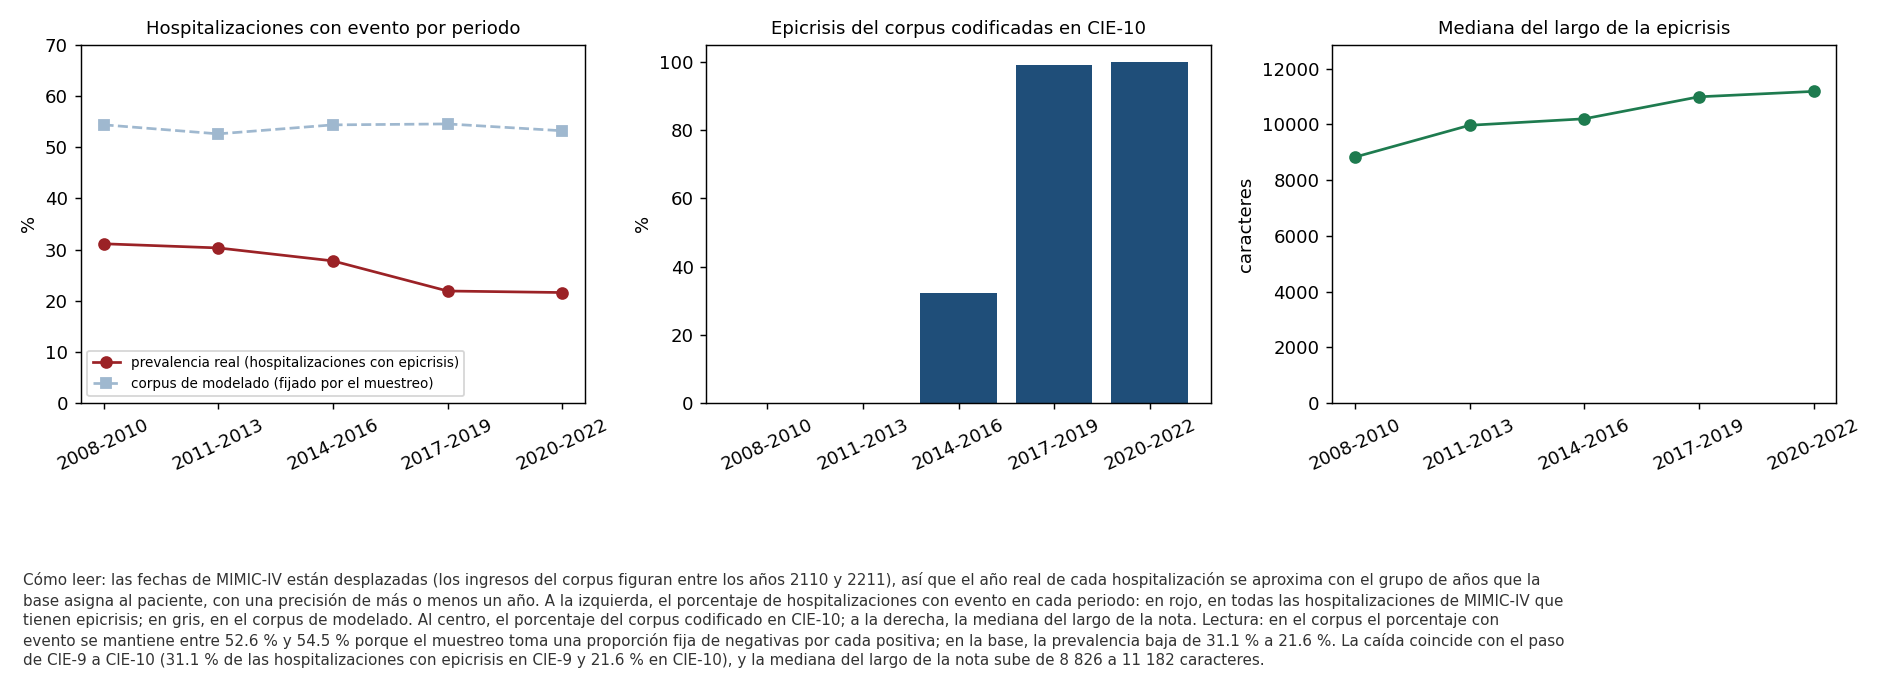

In [18]:
fig("fig_eda_drift.png")

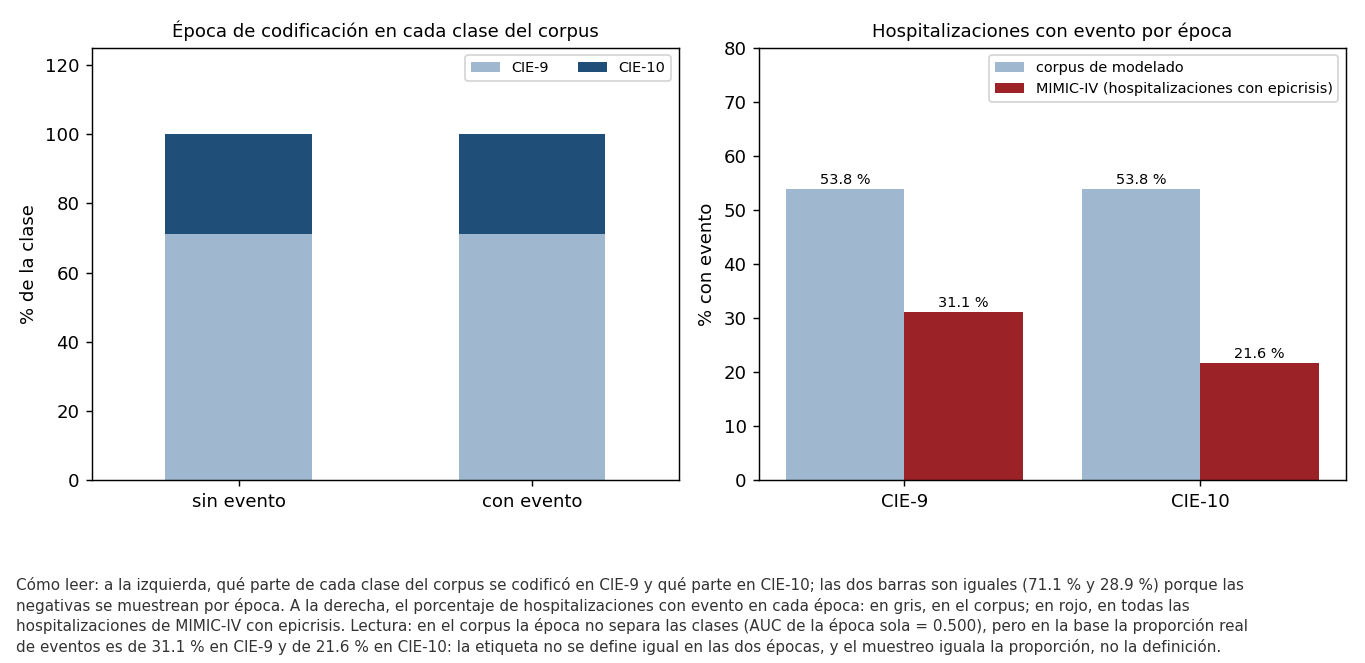

In [19]:
fig("fig_eda_balance_epoca.png")

### Ruido de la etiqueta

In [20]:
neg = N["negativas"]
print("negativas CIE-10:", {k: v for k, v in neg["cie10"].items() if k != "codigos_mas_frecuentes"})
print("negativas CIE-9:", neg["cie9"])
display(pd.DataFrame(neg["cie10"]["codigos_mas_frecuentes"]))
K = N["caidas"]
print("positivas solo por caída:", K["positivas_solo_por_caida"], "·", round(K["pct_de_las_positivas"], 2), "% de las positivas")
display(pd.DataFrame({"CIE-10": {k: v for k, v in K["cie10"].items() if k != "titulos_en_mimic"},
                      "CIE-9": {k: v for k, v in K["cie9"].items() if k != "titulos_en_mimic"}}).T)
print("títulos de los códigos de lugar en el diccionario de MIMIC-IV:", K["cie10"]["titulos_en_mimic"], K["cie9"]["titulos_en_mimic"])
print("% de las positivas de cada servicio que lo son solo por caída:", {k: round(v, 1) for k, v in K["pct_de_las_positivas_del_servicio"].items()})

negativas CIE-10: {'n': 9345, 'con_codigo_de_familia_causal': 451, 'con_efecto_adverso_de_farmaco': 368, 'con_alguno': 805, 'pct_con_alguno': 8.614232}
negativas CIE-9: {'n': 22963, 'con_codigo_de_familia_causal': 0, 'pct': 0.0}


,codigo,epicrisis,titulo_en_mimic
0,T380X5A,102,"Adverse effect of glucocorticoids and synthetic analogues, initial encounter"
1,Y838,88,"Other surgical procedures as the cause of abnormal reaction of the patient, or of late..."
2,Y831,71,Surgical operation with implant of artificial internal device as the cause of abnormal...
3,W010XXA,45,"Fall on same level from slipping, tripping and stumbling without subsequent striking a..."
4,T82855A,24,"Stenosis of coronary artery stent, initial encounter"
5,T447X5A,24,"Adverse effect of beta-adrenoreceptor antagonists, initial encounter"
6,W1789XA,20,"Other fall from one level to another, initial encounter"
7,T502X5A,19,"Adverse effect of carbonic-anhydrase inhibitors, benzothiadiazides and other diuretics..."


positivas solo por caída: 6296 · 16.7 % de las positivas


,n,con_codigo_de_lugar,en_hospital,pct_en_hospital,en_residencia_privada,en_el_hogar,en_institucion_residencial,codigos_de_lugar_en_el_diccionario,algun_codigo_de_lugar_menciona_el_hospital
CIE-10,2010.0,1706.0,159.0,7.910448,884.0,NaN,NaN,NaN,NaN
CIE-9,4286,1630,NaN,NaN,NaN,813,240,"{'E8490': 'Home accidents', 'E8491': 'Farm accidents', 'E8492': 'Mine and quarry accid...",False


títulos de los códigos de lugar en el diccionario de MIMIC-IV: {'Y92.23x': 'Hospital as the place of occurrence of the external cause', 'Y92.0x': 'Non-institutional (private) residence as the place of occurrence of the external cause'} {'E849.0': 'Home accidents', 'E849.7': 'Accidents occurring in residential institution'}
% de las positivas de cada servicio que lo son solo por caída: {'TRAUM': 74.2, 'NSURG': 51.1, 'ORTHO': 47.7, 'NMED': 19.6, 'MED': 15.9}


### Naturaleza del evento

In [21]:
nat = pd.DataFrame({"total": R["naturaleza"]["conteo"], **{k: v["conteo"] for k, v in R["naturaleza"]["por_epoca"].items()}}).fillna(0).astype(int)
display(nat)
print("multietiqueta (%):", round(R["naturaleza"]["pct_multietiqueta"], 2), {k: round(v["pct_multietiqueta"], 2) for k, v in R["naturaleza"]["por_epoca"].items()})

,total,CIE-9,CIE-10
Procedimiento,17209,13005,4204
Cuidado del paciente,10305,7155,3150
Medicacion,9933,6630,3303
Dispositivo medico,1198,0,1198
Infeccion nosocomial,1007,0,1007
Sistema/Organizacion,130,0,130


multietiqueta (%): 4.96 {'CIE-9': 0.0, 'CIE-10': 17.13}


## 5 · Los 231 eventos del Anexo 02

In [22]:
M, O, C = E["mapeo"], E["observado"], E["corpus"]
embudo = pd.Series({"en el catálogo": E["catalogo"]["eventos"], "con código CIE-10 en las tablas": M["eventos_con_codigo"],
                    "observados en MIMIC-IV": O["eventos_del_catalogo_observados"],
                    "observados con código de causa explícita": O["eventos_del_catalogo_con_codigo_de_causa_explicita"],
                    "en las positivas del corpus": C["eventos_del_catalogo"]["presentes"]}, name="eventos")
display(embudo.to_frame())
display(pd.DataFrame(E["por_naturaleza"]).T)
print("tipo de código:", M["eventos_por_tipo_de_codigo"])
print("con código por nivel de detección:", M["con_codigo_por_nivel_de_deteccion"])
print("filas de la tabla:", M["filas"], "· enlazadas al catálogo:", M["filas_enlazadas_al_catalogo"], "· sin enlace:", M["filas_sin_enlace"], M["filas_sin_enlace_detalle"])

,eventos
en el catálogo,231
con código CIE-10 en las tablas,128
observados en MIMIC-IV,78
observados con código de causa explícita,23
en las positivas del corpus,22


,en_el_catalogo,con_codigo,observados,con_codigo_de_causa_explicita,en_las_positivas_del_corpus
INFECCIÓN ASOCIADA,49,31,27,3,2
PROCEDIMIENTO,34,24,20,10,10
MEDICACIÓN,33,17,6,2,2
HISTORIA CLÍNICA,23,0,0,0,0
GESTIÓN ORGANIZACIÓN,21,12,7,3,3
CUIDADO DEL PACIENTE,19,10,8,2,2
SANGRE/HEMODERIVADOS,19,13,2,2,2
COMPORTAMIENTO,14,10,5,0,0
DISPOSITIVO MÉDICO,9,4,3,1,1
NUTRICIÓN,6,5,0,0,0


tipo de código: {'sin código': 103, 'código propio': 54, 'código compartido con otro evento': 41, 'código aproximado (proxy)': 29, 'equivalencia CIE-10-CM': 4}
con código por nivel de detección: {'A': {'eventos': 94, 'con_codigo': 62}, 'B': {'eventos': 60, 'con_codigo': 50}, 'C': {'eventos': 11, 'con_codigo': 8}, 'D': {'eventos': 23, 'con_codigo': 4}, 'E': {'eventos': 43, 'con_codigo': 4}}
filas de la tabla: 272 · enlazadas al catálogo: 137 · sin enlace: 135 {'identificador_fuera_del_catalogo': 68, 'identificador_de_otra_naturaleza': 60, 'misma_naturaleza_y_otro_evento': 7}


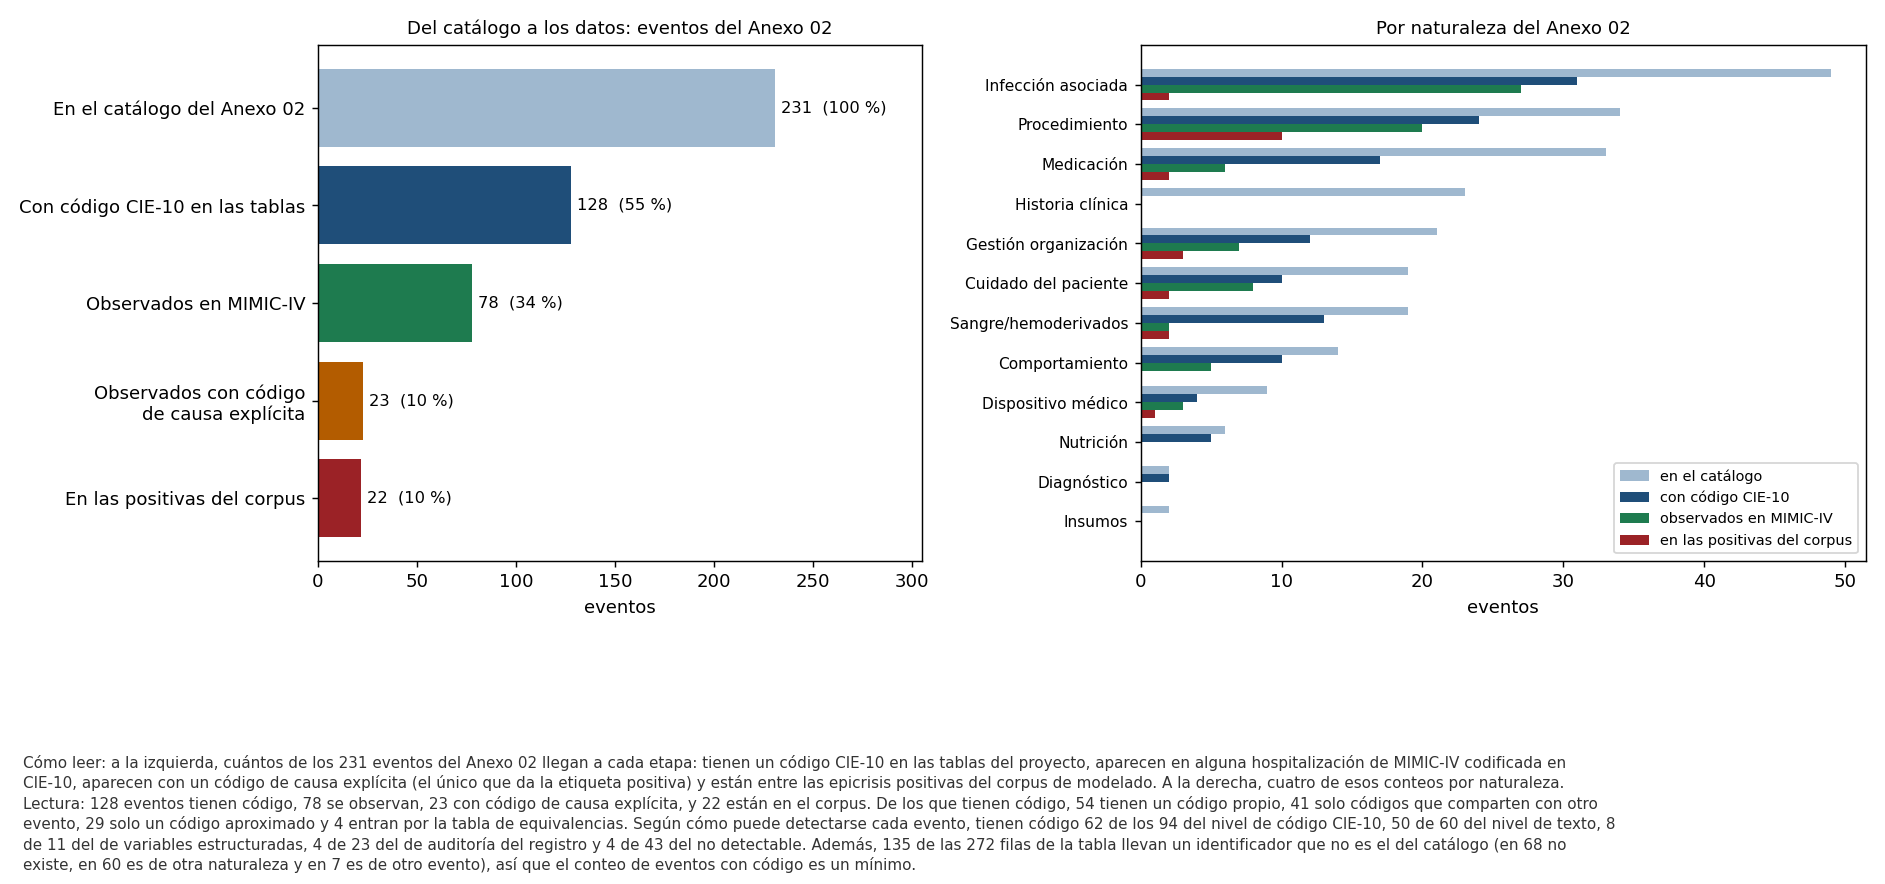

In [23]:
fig("fig_eda_eventos_catalogo.png")

In [24]:
ev = pd.read_csv(REP / "eda_eventos_231.csv")
print(len(ev), "eventos · una fila por evento")
display(ev[ev.epicrisis_positivas_en_el_corpus != "0"].reset_index(drop=True))
display(pd.DataFrame(O["top"]))
print("corpus:", {k: v for k, v in C.items() if k not in ("familias_cie9", "equivalencias_cie10cm")})
print("familias CIE-9:", C["familias_cie9"])

231 eventos · una fila por evento


,id_evento,evento,naturaleza,nivel_de_deteccion,tipo_de_codigo,hospitalizaciones_con_codigo_de_causa_explicita,hospitalizaciones_con_codigo_de_condicion,epicrisis_positivas_en_el_corpus
0,202,Caída de paciente,Cuidado del paciente,código CIE-10,código propio,5551,5652,2318
1,203,Desplazamiento de dispositivos invasivos,Cuidado del paciente,texto de las notas,código propio,99,0,40
2,402,Desplazamiento/conexión incorrecta/extravasación,Dispositivo médico,texto de las notas,código propio,132,0,54
3,601,Infección del torrente sanguíneo,Infección asociada,código CIE-10,equivalencia CIE-10-CM,105,11797,15
4,604,Infección del sitio quirúrgico superficial,Infección asociada,código CIE-10,equivalencia CIE-10-CM,267,0,32
5,7010,Hemorragia/hematoma por anticoagulación,Medicación,código CIE-10,equivalencia CIE-10-CM,1198,0,198
6,7021,Reacción adversa al medicamento,Medicación,código CIE-10,código compartido con otro evento,14090,0,3240
7,804,Desplazamiento de dispositivo intracardiaco,Procedimiento,código CIE-10,código propio,<10,0,<10
8,808,Hematoma por punción,Procedimiento,código CIE-10,código compartido con otro evento,223,0,41
9,809,Hematoma post cateterismo cardiaco,Procedimiento,código CIE-10,código compartido con otro evento,92,0,16


,evento,hospitalizaciones,con_codigo_de_causa_explicita,en_el_catalogo
0,Falla renal aguda no especificada,19705,0,False
1,Reacción adversa al medicamento,14090,14090,True
2,Infección del torrente sanguíneo,11826,105,True
3,Otras infecciones del trato urinario,9659,0,True
4,Caída de paciente,8326,5551,True
5,Insuficiencia respiratoria aguda,6959,0,False
6,Neumonia organismo no especificado,5790,0,False
7,Estreptococos/estafilococos como causa,5017,0,False
8,Sepsis no especificada,4481,0,False
9,Otros procedimientos medicos causa reaccion,3021,3021,False


corpus: {'positivas': 37692, 'con_evento_del_catalogo': 6801, 'pct_con_evento_del_catalogo': 18.043617, 'solo_complicacion_sin_enlace': 4100, 'pct_solo_complicacion_sin_enlace': 10.87764, 'solo_familia_cie9': 26791, 'pct_solo_familia_cie9': 71.078743, 'eventos_del_catalogo': {'presentes': 22, 'con_100_epicrisis_o_mas': 8, 'con_30_epicrisis_o_mas_en_test': 7}}
familias CIE-9: {'complicaciones_atencion': 11504, 'farmacos_uso_terapeutico': 6630, 'caidas': 4419, 'ulcera_presion': 2737, 'incidentes_asistenciales': 1501}


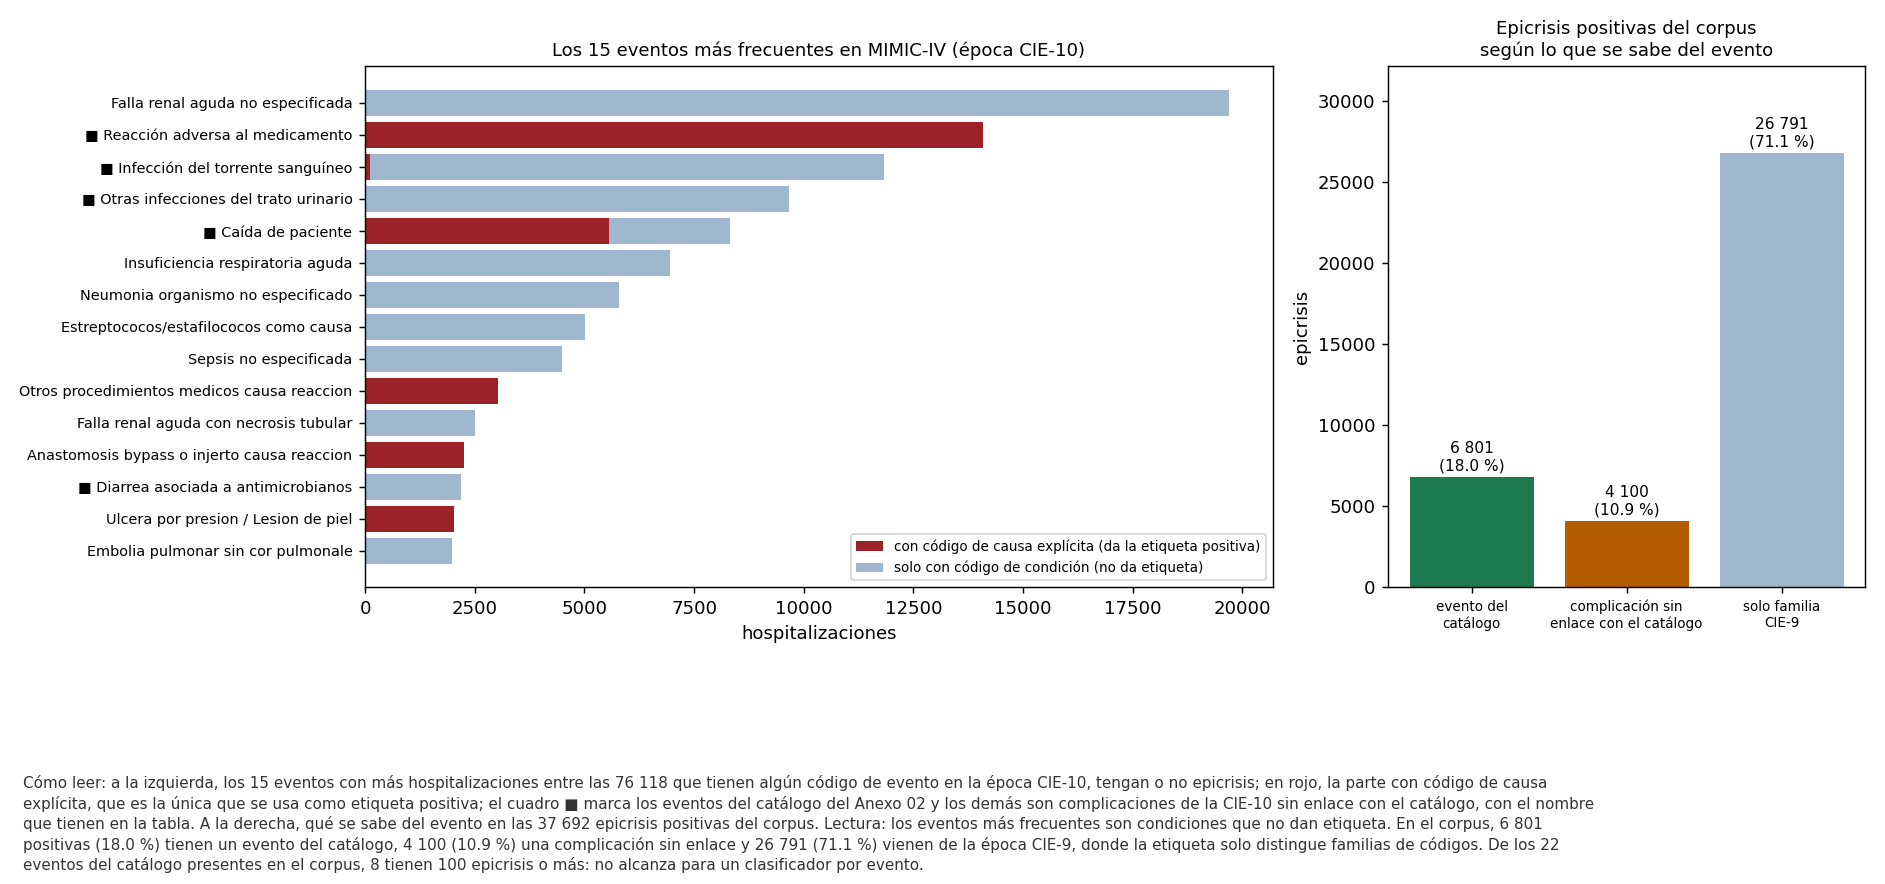

In [25]:
fig("fig_eda_eventos_frecuencia.png")

## 6 · Correlaciones

,Spearman con y
n.º de diagnósticos,0.415
estancia (días),0.306
severidad APR-DRG,0.293
largo (caracteres),0.182
paso por UCI,0.144
edad,0.144
notas del paciente,0.125
fallecimiento,0.065
reingreso a 30 días,0.065
sexo (hombre),0.029


,a,b,rho
0,severidad APR-DRG,n.º de diagnósticos,0.6373
1,largo (caracteres),n.º de diagnósticos,0.5589
2,largo (caracteres),estancia (días),0.4677
3,n.º de diagnósticos,estancia (días),0.4614


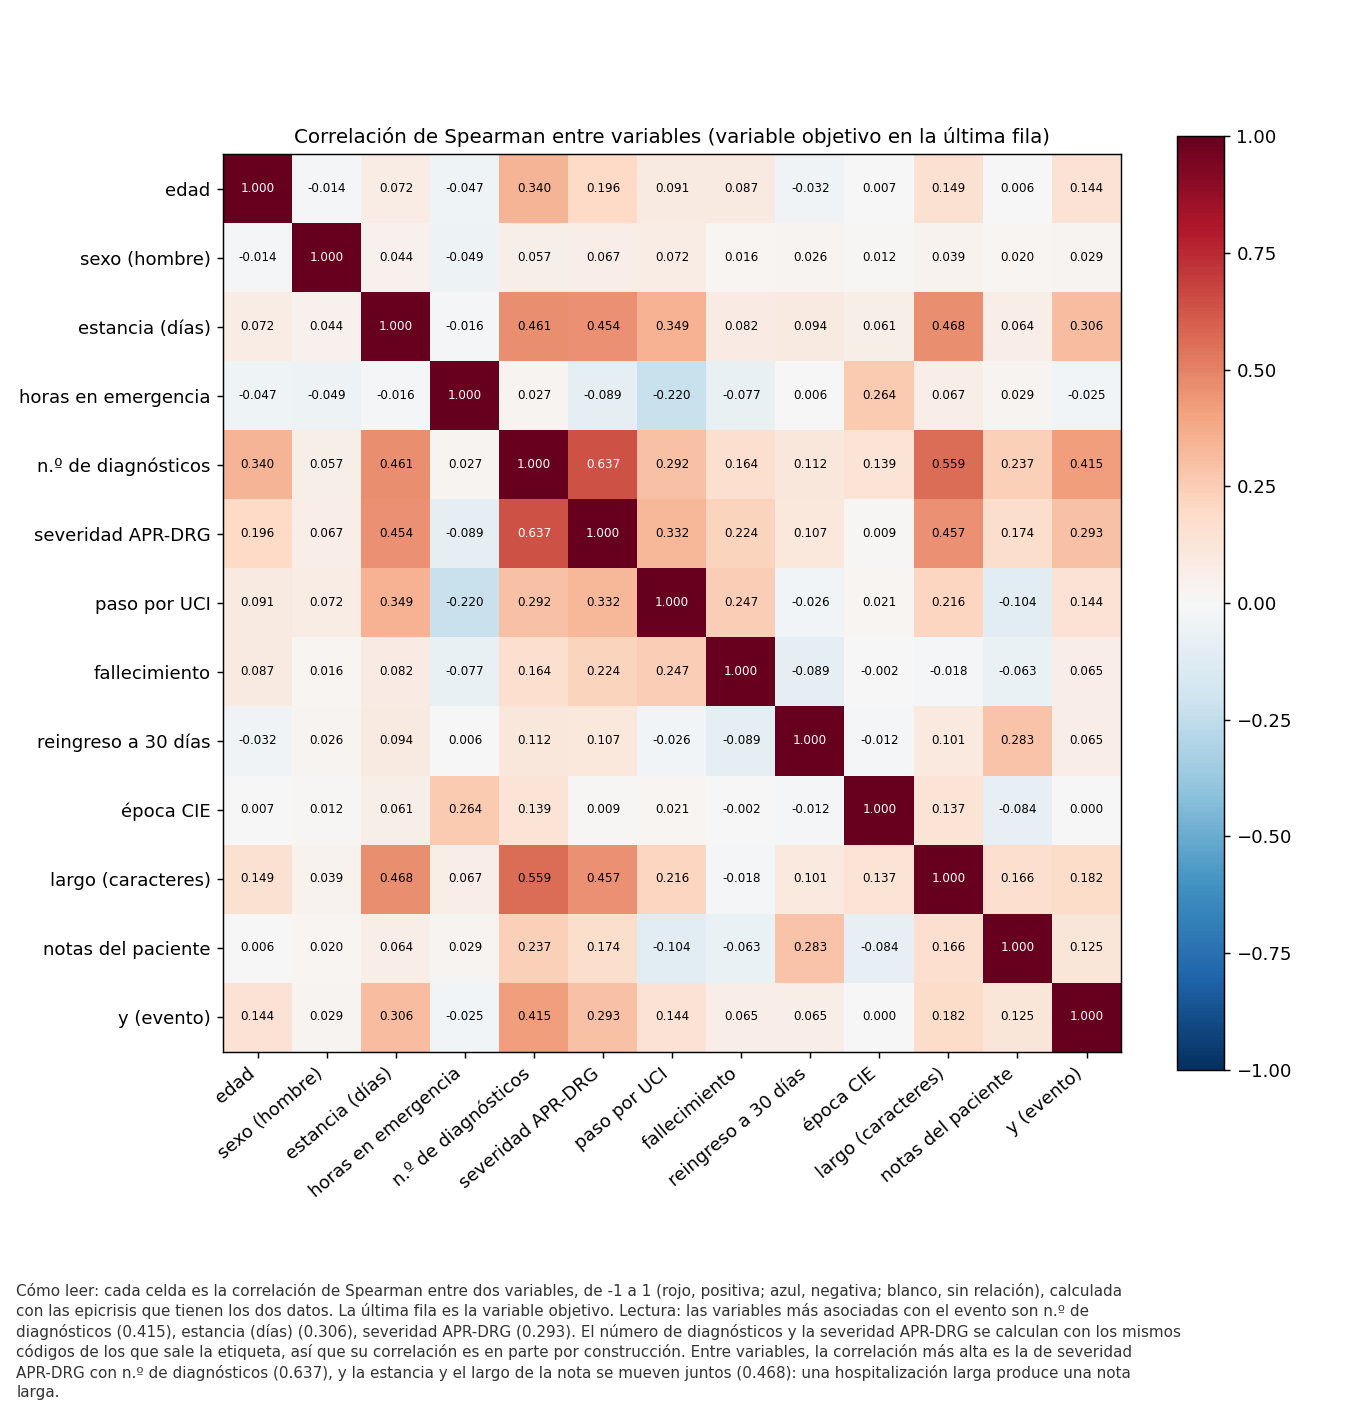

In [26]:
display(pd.Series(R["correlaciones_spearman"]["con_y"], name="Spearman con y").sort_values(key=abs, ascending=False).round(3).to_frame())
display(pd.DataFrame(R["correlaciones_spearman"]["pares_mas_correlacionados"]))
fig("fig_eda_correlaciones.png")

## Riesgos y decisiones

In [27]:
for k, v in R["riesgos"].items():
    print("-", k + ":", v)

- desbalance: corpus de modelado con 53.8 % de positivas; prevalencia real de 27.6 % entre las hospitalizaciones con epicrisis (20.1 % sobre todas las hospitalizaciones)
- leakage_etiqueta: códigos de las familias de la etiqueta escritos en 44 notas (0.10 % de las positivas, 0.02 % de las negativas)
- leakage_paciente: 0 pacientes compartidos entre train y test
- drift_de_la_etiqueta: prevalencia real de 31.1 % en la época CIE-9 y de 21.6 % en la CIE-10; en el corpus el muestreo por época la iguala
- atajo_largo: AUC del largo solo 0.606; positivas por decil 44.0 % → 76.5 %
- clases_raras_etapa2: ['Sistema/Organizacion']
- naturalezas_solo_en_una_epoca: ['Dispositivo medico', 'Infeccion nosocomial', 'Sistema/Organizacion']
- etiqueta_debil: la etiqueta sale de códigos de diagnóstico de facturación, no de una lectura clínica de la nota
- ruido_en_negativas: 8.6 % de las negativas CIE-10 llevan un código de las familias de causa explícita que no está en la tabla
- ruido_en_positivas: 16.

In [28]:
for d in R["decisiones"]:
    print(f"{d['n']}. {d['decision']} [{d['paso']}]\n   Evidencia: {d['evidencia']}\n   Control: {d['control']}\n")
print("Otras acciones registradas:")
for a in R["acciones_registradas"]:
    print("-", a)

1. Excluir de la clase negativa las hospitalizaciones que tengan cualquier código de las familias de causa explícita [Preprocesado]
   Evidencia: 805 de las 9345 negativas de la época CIE-10 (8.6 %) llevan un código de esas familias (T80 a T88, Y63, Y65, Y83, Y84, W00 a W19, L89 o efecto adverso de medicamento) que no está en la tabla del proyecto; en la época CIE-9, donde se usan las familias completas, son 0
   Control: porcentaje de negativas CIE-10 con código de esas familias: hoy 8.6 %, debe quedar en 0 % al regenerar el corpus; se reporta la PR-AUC antes y después

2. Dejar como positivas por caída solo las que tienen el hospital como lugar de ocurrencia y sacar las demás de las dos clases [Preprocesado]
   Evidencia: 6296 positivas (16.7 %) lo son solo por un código de caída; en la época CIE-10, de 2010 solo 159 (7.9 %) tienen el hospital como lugar de ocurrencia y 884 una residencia privada; 2960 no tienen código de lugar y en la época CIE-9 ningún código de lugar corresponde a